In [2]:
import pandas as pd
file = "Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv"
df=pd.read_csv(file)

In [3]:
df

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,...,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Race/Ethnicity,2 or more races,RACE,RACE2PLUS
1,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,...,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Race/Ethnicity,Other,RACE,RACEOTH
2,2011,2011,AK,Alaska,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who achieve at least 150 min...,2011.0,Value,...,"(64.845079957001, -147.722059036)",PA,PA1,Q044,VALUE,2,Sex,Female,SEX,FEMALE
3,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,...,"(64.845079957001, -147.722059036)",OWS,OWS1,Q036,VALUE,2,Age (years),35 - 44,AGEYR,AGEYR3544
4,2011,2011,AK,Alaska,BRFSS,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,2011.0,Value,...,"(64.845079957001, -147.722059036)",OWS,OWS1,Q037,VALUE,2,Income,"$15,000 - $24,999",INC,INC1525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104267,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,...,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q047,VALUE,56,Education,High school graduate,EDU,EDUHSGRAD
104268,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,...,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q047,VALUE,56,Age (years),65 or older,AGEYR,AGEYR65PLUS
104269,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in no leisure-tim...,NaN,Value,...,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q047,VALUE,56,Income,Data not reported,INC,INCNR
104270,2023,2023,WY,Wyoming,BRFSS,Physical Activity,Physical Activity - Behavior,Percent of adults who engage in muscle-strengt...,NaN,Value,...,"(43.23554134300048, -108.10983035299967)",PA,PA1,Q046,VALUE,56,Education,Less than high school,EDU,EDUHS



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104272 entries, 0 to 104271
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   104272 non-null  int64  
 1   YearEnd                     104272 non-null  int64  
 2   LocationAbbr                104272 non-null  object 
 3   LocationDesc                104272 non-null  object 
 4   Datasource                  104272 non-null  object 
 5   Class                       104272 non-null  object 
 6   Topic                       104272 non-null  object 
 7   Question                    104272 non-null  object 
 8   Data_Value_Unit             88872 non-null   float64
 9   Data_Value_Type             104272 non-null  object 
 10  Data_Value                  93505 non-null   float64
 11  Data_Value_Alt              93505 non-null   float64
 12  Data_Value_Footnote_Symbol  10767 non-null   objec

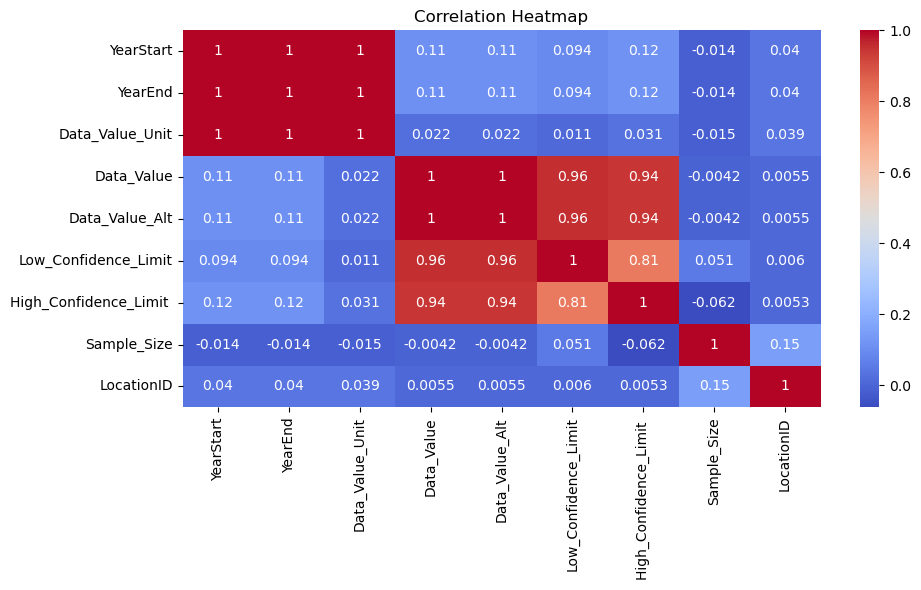

In [5]:
#DATA CLEANING
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset directly
df = pd.read_csv('Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv')

# 2. Basic data cleaning (optional: remove completely empty columns/rows)
df.dropna(axis=1, how='all', inplace=True)  # Drop columns with all missing values
df.dropna(axis=0, how='all', inplace=True)  # Drop rows with all missing values

# 3. Dataset Overview
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())

# 4. Missing Value Check
print("\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0])

# 5. Unique Values per Column
print("\n--- Unique Values per Column ---")
print(df.nunique())

# 6. Summary Statistics for Numeric Columns
print("\n--- Summary Statistics ---")
print(df.describe())

# 7. Categorical Distributions
categorical_cols = ['locationdesc', 'gender', 'age(years)', 'income', 'class', 'topic']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n--- Value Counts: {col} ---")
        print(df[col].value_counts().head())

# 8. Correlation Heatmap
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 9. Top 5 and Bottom 5 Obesity Values
if 'data_value' in df.columns and 'class' in df.columns:
    obesity_df = df[df['class'] == 'obesity_/_weight_status']
    print("\n--- Top 5 Highest Obesity Rates ---")
    print(obesity_df.sort_values(by='data_value', ascending=False)[['locationdesc', 'data_value']].head())

    print("\n--- Bottom 5 Lowest Obesity Rates ---")
    print(obesity_df.sort_values(by='data_value', ascending=True)[['locationdesc', 'data_value']].head())


Top 10 States with Highest Average Obesity Rates:
    LocationDesc  Data_Value
0  West Virginia   35.491639
1    Mississippi   35.463559
2      Louisiana   34.826161
3        Alabama   34.821672
4       Arkansas   34.704601
5       Oklahoma   34.487164
6   North Dakota   34.359646
7    Puerto Rico   34.310606
8      Tennessee   34.262898
9       Kentucky   34.194276


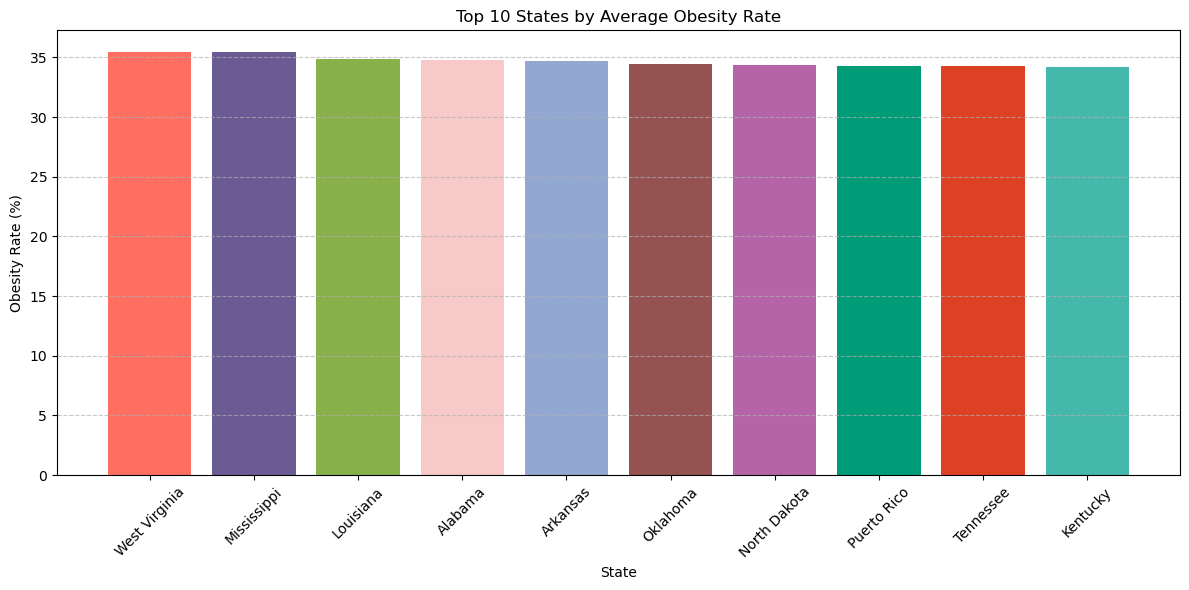

In [6]:

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the dataset
file_path = 'Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv'
df = pd.read_csv(file_path)

# Step 2: Filter only obesity-related data
obesity_df = df[df['Class'] == 'Obesity / Weight Status']

# Step 3: Drop rows with missing obesity values
obesity_df = obesity_df.dropna(subset=['Data_Value'])

# Step 4: Group by state and calculate average obesity rate
state_avg_obesity = obesity_df.groupby('LocationDesc')['Data_Value'].mean().reset_index()

# Step 5: Sort states by average obesity (descending order)
leaderboard = state_avg_obesity.sort_values(by='Data_Value', ascending=False).reset_index(drop=True)

# Step 6: Display the top 10 states
print("Top 10 States with Highest Average Obesity Rates:")
print(leaderboard.head(10))

# Step 7: Plot bar chart for top 10 with custom colors
top_10 = leaderboard.head(10)

# Define a list of distinct colors
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1',
          '#955251', '#B565A7', '#009B77', '#DD4124', '#45B8AC']

plt.figure(figsize=(12, 6))
plt.bar(top_10['LocationDesc'], top_10['Data_Value'], color=colors)
plt.title('Top 10 States by Average Obesity Rate')
plt.xlabel('State')
plt.ylabel('Obesity Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


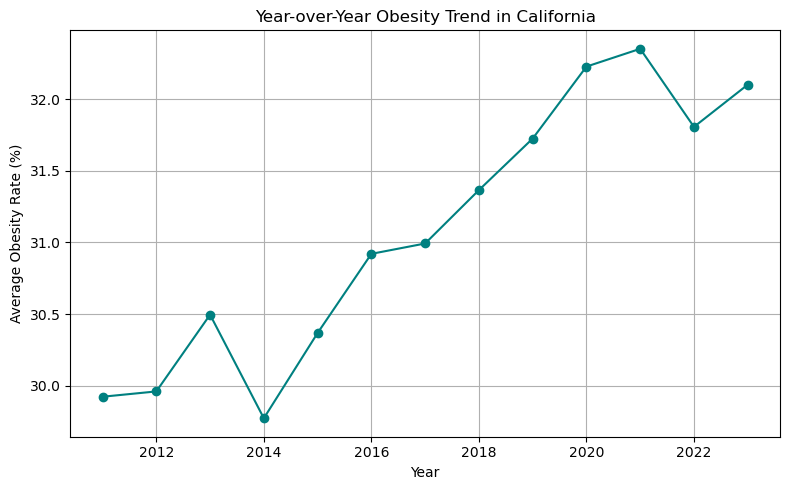

In [7]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv'
df = pd.read_csv(file_path)

# Filter for Obesity data in California
state = 'California'  # Change this to any other state if needed
obesity_trend = df[(df['Class'] == 'Obesity / Weight Status') & 
                   (df['LocationDesc'] == state)]

# Drop missing values
obesity_trend = obesity_trend.dropna(subset=['Data_Value'])

# Group by year and calculate average obesity rate
yearly_avg = obesity_trend.groupby('YearStart')['Data_Value'].mean().reset_index()

# Plotting the trend
plt.figure(figsize=(8, 5))
plt.plot(yearly_avg['YearStart'], yearly_avg['Data_Value'], marker='o', linestyle='-', color='teal')
plt.title(f'Year-over-Year Obesity Trend in {state}')
plt.xlabel('Year')
plt.ylabel('Average Obesity Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


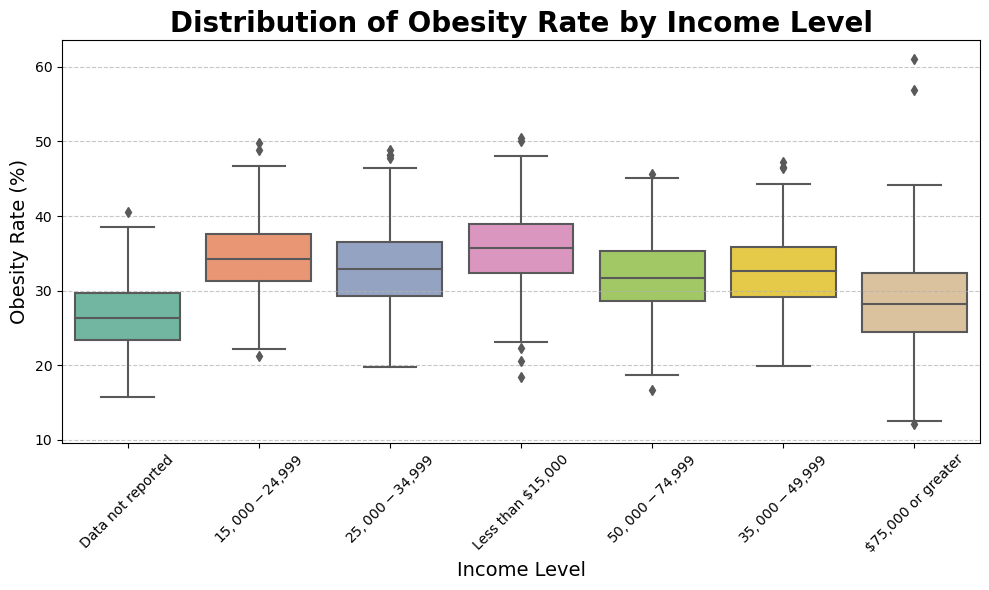

In [8]:

# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
file_path = 'Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv'
df = pd.read_csv(file_path, encoding='ascii')

# Filtering the data for Obesity Rate and Income Level
obesity_data = df[(df['Class'] == 'Obesity / Weight Status') & (df['Question'] == 'Percent of adults aged 18 years and older who have obesity')]

# Grouping by Income Level and calculating the mean obesity rate
income_obesity = obesity_data.groupby('Income')['Data_Value'].mean().reset_index()

# Plotting the data
plt.figure(figsize=(10, 6))
sns.boxplot(data=obesity_data, x='Income', y='Data_Value', palette='Set2')
plt.title('Distribution of Obesity Rate by Income Level', fontsize=20, fontweight='semibold')
plt.xlabel('Income Level', fontsize=14)
plt.ylabel('Obesity Rate (%)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


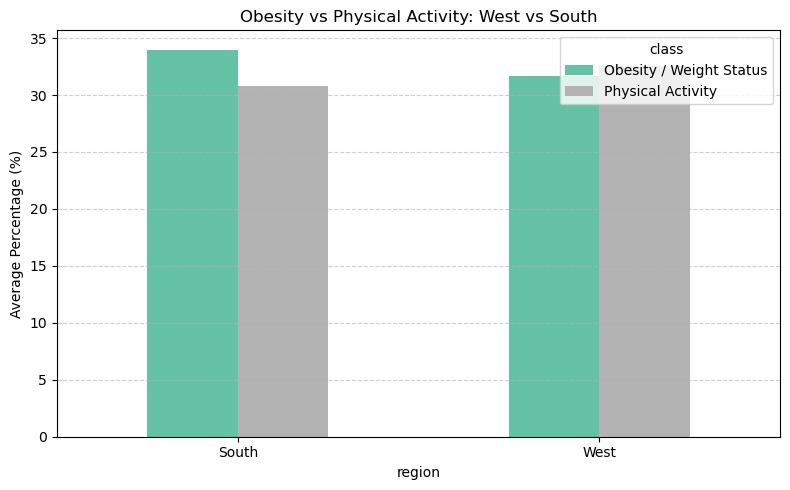

class   Obesity / Weight Status  Physical Activity
region                                            
South                 33.980794          30.760971
West                  31.631990          32.543069


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean dataset
df = pd.read_csv("Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Filter to keep only relevant classes
df = df[df['class'].isin(['Obesity / Weight Status', 'Physical Activity'])]

# Drop missing values
df = df.dropna(subset=['data_value'])

# Define U.S. Census Regions (can be customized)
regions = {
    'West': ['California', 'Oregon', 'Washington', 'Nevada', 'Utah', 'Colorado', 'Arizona', 'New Mexico', 'Hawaii', 'Alaska', 'Idaho', 'Montana', 'Wyoming'],
    'South': ['Texas', 'Florida', 'Georgia', 'Alabama', 'Mississippi', 'South Carolina', 'North Carolina', 'Tennessee', 'Arkansas', 'Louisiana', 'Kentucky', 'West Virginia', 'Virginia', 'Oklahoma']
}

# Assign region to each state
df['region'] = df['locationdesc'].apply(
    lambda x: 'West' if x in regions['West'] else ('South' if x in regions['South'] else 'Other')
)

# Filter only West and South
df_region = df[df['region'].isin(['West', 'South'])]

# Calculate average obesity and physical activity per region
summary = df_region.groupby(['region', 'class'])['data_value'].mean().unstack()

# Plotting
summary.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title('Obesity vs Physical Activity: West vs South')
plt.ylabel('Average Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Print the summary table
print(summary)
